Advanced Marketing Mix Modeling (MMM)

Objective-The aim of this project is to build an Advanced Marketing Mix Model to understand how different marketing channels influence sales. In this project, feature engineering techniques like Adstock, Saturation and Lag are used to make the model more realistic.

In [1]:
import numpy as np
import pandas as pd

First, the dataset is loaded and basic information is checked to understand its structure.

In [2]:
df=pd.read_csv("synthetic_mmm_weekly_india_SAT.csv");

In [3]:
df.head

<bound method NDFrame.head of              Week      Geo   Brand          SKU  Sales_Units   Sales_Value  \
0      2022-07-02  CENTRAL  BrandA  BrandA_SKU1   166.737425  15058.472804   
1      2022-07-02  CENTRAL  BrandA  BrandA_SKU2   123.326990  11166.439172   
2      2022-07-02  CENTRAL  BrandA  BrandA_SKU3    74.232953   7829.352426   
3      2022-07-02  CENTRAL  BrandB  BrandB_SKU1   216.583770  15986.585046   
4      2022-07-02  CENTRAL  BrandB  BrandB_SKU2   272.920195  22565.283219   
...           ...      ...     ...          ...          ...           ...   
11227  2025-06-21     WEST  BrandB  BrandB_SKU2   464.265398  34966.742688   
11228  2025-06-21     WEST  BrandB  BrandB_SKU3  1102.182610  72163.074413   
11229  2025-06-21     WEST  BrandC  BrandC_SKU1  1144.234814  54845.202065   
11230  2025-06-21     WEST  BrandC  BrandC_SKU2   318.221874  15948.330673   
11231  2025-06-21     WEST  BrandC  BrandC_SKU3  1665.215418  92144.243476   

              MRP   Net_Price  Fe

In [4]:
df.shape

(11232, 28)

In [5]:
df = df[
    (df["Geo"] == "METRO_DELHI") &
    (df["Brand"] == "BrandA") &
    (df["SKU"] == "BrandA_SKU1")
].copy()

In [6]:
df.shape

(156, 28)

Data Cleaning
The data is checked for missing values, duplicate records and incorrect data types to make sure it is ready for analysis.

In [7]:
df.isnull().sum()

Week                       0
Geo                        0
Brand                      0
SKU                        0
Sales_Units                0
Sales_Value                0
MRP                        0
Net_Price                  0
Feature_Flag               0
Display_Flag               0
TPR_Flag                   0
Trade_Spend                0
TV_Impressions             0
YouTube_Impressions        0
Facebook_Impressions       0
Instagram_Impressions      0
Print_Readership           0
Radio_Listenership         0
FB_Banner_Content_Score    0
IG_Banner_Content_Score    0
Weighted_Distribution      0
Numeric_Distribution       0
TDP                        0
NOS                        0
CPI                        0
GDP_Growth                 0
Festival_Index             0
Rainfall_Index             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Week                        object
Geo                         object
Brand                       object
SKU                         object
Sales_Units                float64
Sales_Value                float64
MRP                        float64
Net_Price                  float64
Feature_Flag                 int64
Display_Flag                 int64
TPR_Flag                     int64
Trade_Spend                float64
TV_Impressions             float64
YouTube_Impressions        float64
Facebook_Impressions       float64
Instagram_Impressions      float64
Print_Readership           float64
Radio_Listenership         float64
FB_Banner_Content_Score    float64
IG_Banner_Content_Score    float64
Weighted_Distribution      float64
Numeric_Distribution       float64
TDP                        float64
NOS                        float64
CPI                        float64
GDP_Growth                 float64
Festival_Index             float64
Rainfall_Index             float64
dtype: object

Exploratory Data Analysis (EDA)

EDA is performed to understand the data better. Different charts are used to identify trends, distributions, outliers and relationships between variables.

In [10]:
df["Week"] = pd.to_datetime(df["Week"])

In [11]:
import matplotlib.pyplot as plt

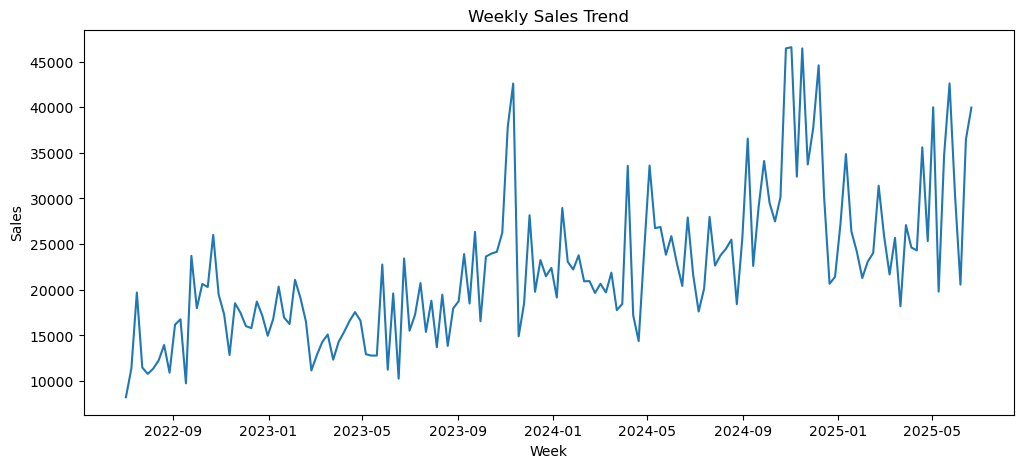

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df["Week"], df["Sales_Value"])
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.show()

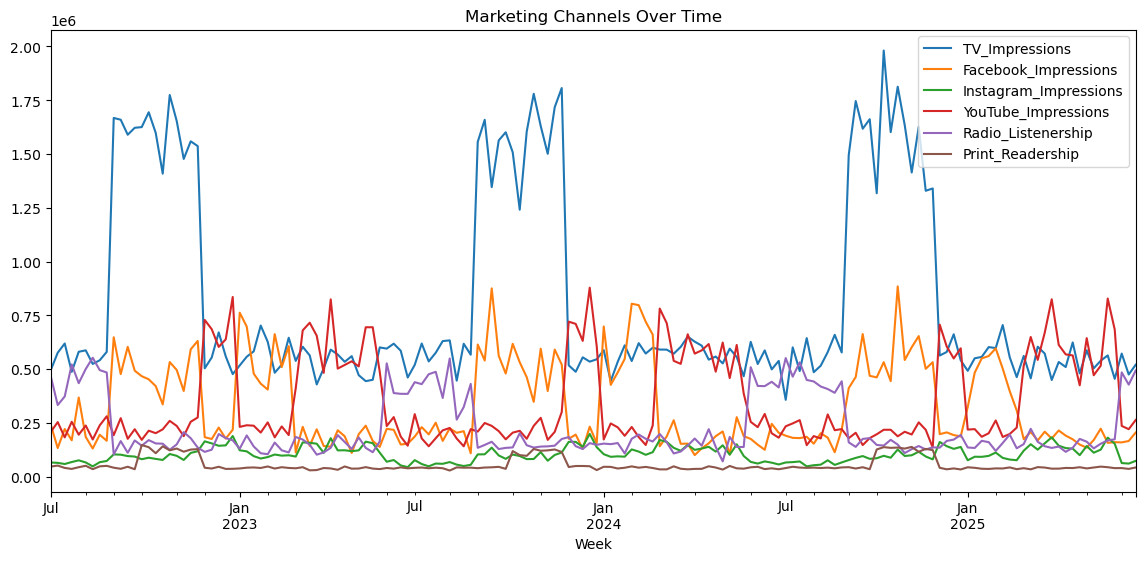

In [13]:
marketing_cols = [
    "TV_Impressions",
    "Facebook_Impressions",
    "Instagram_Impressions",
    "YouTube_Impressions",
    "Radio_Listenership",
    "Print_Readership"
]

df.set_index("Week")[marketing_cols].plot(figsize=(14,6))
plt.title("Marketing Channels Over Time")
plt.show()

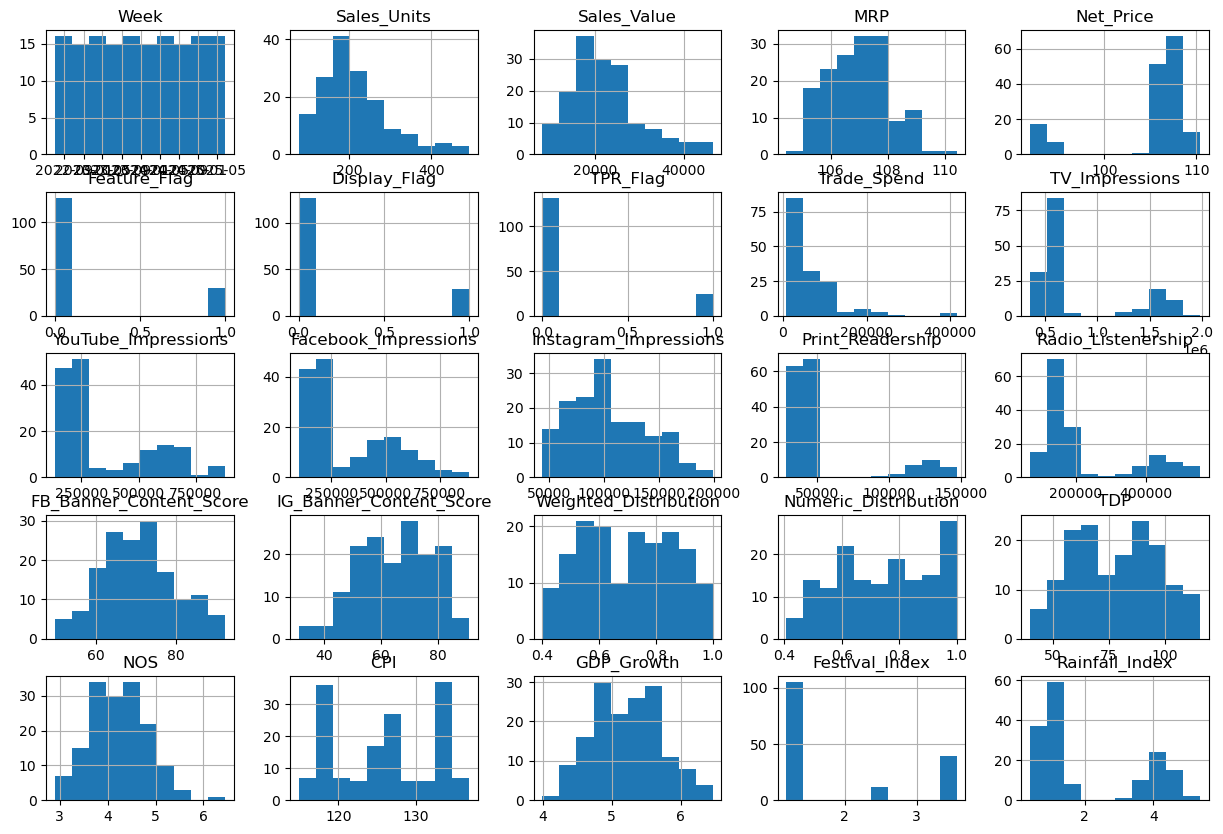

In [14]:
df.hist(figsize=(15,10))
plt.show()

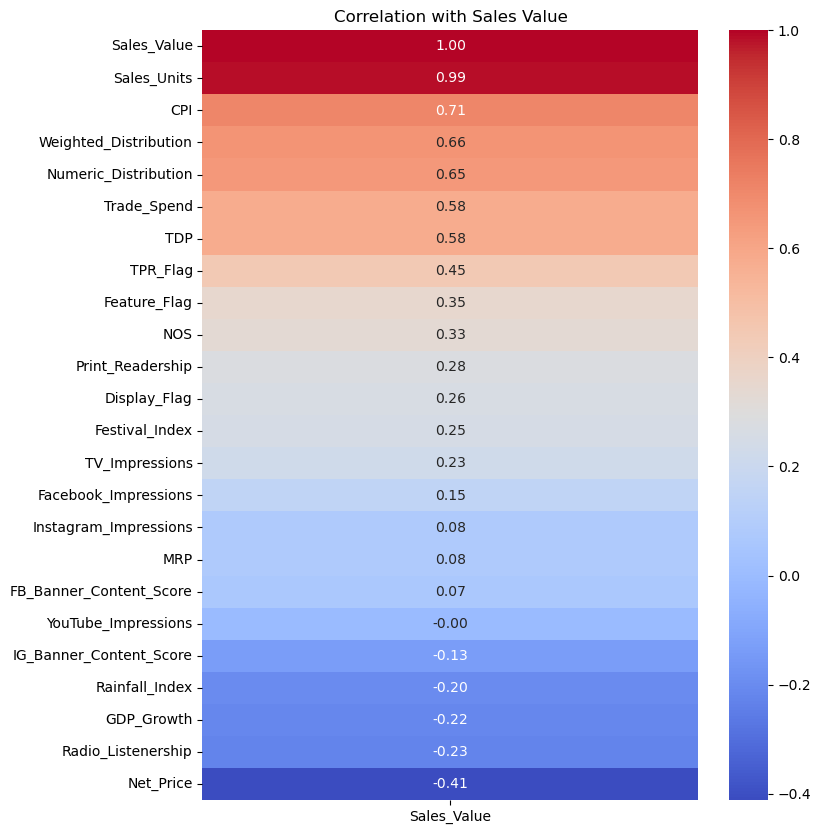

In [15]:
import seaborn as sns
plt.figure(figsize=(8,10))

sales_corr = df.corr(numeric_only=True)[["Sales_Value"]].sort_values(
    by="Sales_Value",
    ascending=False
)

sns.heatmap(
    sales_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation with Sales Value")

plt.show()

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[marketing_cols])
plt.show()

In [ ]:
df["Month"] = df["Week"].dt.month

monthly_sales = df.groupby("Month")["Sales_Value"].mean()

monthly_sales.plot(kind="bar")
plt.title("Average Monthly Sales")
plt.show()

In [ ]:
scatter_cols = [
    "TV_Impressions",
    "Facebook_Impressions",
    "Instagram_Impressions",
    "YouTube_Impressions",
    "Radio_Listenership",
    "Print_Readership",
    "Trade_Spend",
    "Net_Price"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes = axes.flatten()

for i, col in enumerate(scatter_cols):

    axes[i].scatter(df[col], df["Sales_Value"])

    axes[i].set_title(col)

    axes[i].set_xlabel(col)

    axes[i].set_ylabel("Sales")

plt.tight_layout()

plt.show()

Adstock Transformation-Marketing campaigns do not affect sales only in the same week. Customers remember advertisements for some time. Adstock is used to capture this carryover effect.

In [ ]:
adstock_cols = [
    "TV_Impressions",
    "Facebook_Impressions",
    "Instagram_Impressions",
    "YouTube_Impressions",
    "Radio_Listenership",
    "Print_Readership"
]

we are supposing the decay rate=0.5

In [ ]:
decay = 0.5

In [ ]:
def adstock(variable, decay):

    result = []

    previous = 0

    for value in variable:

        current = value + decay * previous

        result.append(current)

        previous = current

    return result

In [ ]:
for col in adstock_cols:

    df[col + "_Adstock"] = adstock(df[col], decay)

In [ ]:
df[[
    "TV_Impressions",
    "TV_Impressions_Adstock"
]].head(10)

Saturation Transformation-Increasing marketing spend does not always increase sales at the same rate. Saturation is applied to capture the diminishing returns of advertising.

In [ ]:
for col in adstock_cols:

    df[col + "_Saturation"] = np.log1p(df[col + "_Adstock"])

In [ ]:
df[[
    "TV_Impressions",
    "TV_Impressions_Adstock",
    "TV_Impressions_Saturation"
]].head(10)

In [ ]:
df.filter(like="_Adstock").head()

In [ ]:
df.filter(like="_Saturation").head()

Lag Features-Some marketing activities influence customer purchases after a delay. Lag features are created to capture this delayed response.

In [ ]:
lag_cols = [
    "TV_Impressions",
    "Facebook_Impressions",
    "Instagram_Impressions",
    "YouTube_Impressions",
    "Radio_Listenership",
    "Print_Readership"
]

In [ ]:
for col in lag_cols:

    df[col + "_Lag1"] = df[col].shift(1)

In [ ]:
df[[
    "TV_Impressions",
    "TV_Impressions_Lag1"
]].head(10)

Feature Selection- Different features were created during feature engineering. The final set of features is selected based on business understanding and to avoid multicollinearity.

In [ ]:
marketing_features = [
    "TV_Impressions_Adstock",
    "Facebook_Impressions_Adstock",
    "Instagram_Impressions_Adstock",
    "YouTube_Impressions_Adstock",
    "Radio_Listenership_Adstock",
    "Print_Readership_Adstock"
]

In [ ]:
pricing_promotion_features = [
    "Trade_Spend",
    "Net_Price",
    "Feature_Flag",
    "Display_Flag",
    "TPR_Flag"
]

In [ ]:
distribution_features = [
    "Weighted_Distribution",
    "Numeric_Distribution"
]

In [ ]:
market_features = [
    "GDP_Growth",
    "CPI",
    "Festival_Index",
    "Rainfall_Index"
]

In [ ]:
features = (
    marketing_features
    + pricing_promotion_features
    + distribution_features
    + market_features
)

In [ ]:
target = "Sales_Value"

In [ ]:
X = df[features]
y = df[target]

In [ ]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

In [ ]:
print(X.columns)

In this project, Adstock, Saturation and Lag features were created to better represent real-world marketing behaviour.
The final model uses the most relevant features for prediction.

Model Building-we are building the model using Multiple Linear Regression.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

In [ ]:
y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

In [ ]:
comparison_df = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_test_pred
})

comparison_df.head(10)

After building the Marketing Mix Model, we need to evaluate how well it predicts sales.
The evaluation metrics include:
- R² Score
- MAE
- MSE
- RMSE

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)


we will first tran the metrics.

In [ ]:
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)

then we will test the metrics

In [ ]:
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

the last step is to display the results

In [ ]:
results = {
    "Metric": ["R² Score", "MAE", "MSE", "RMSE"],
    "Training": [
        train_r2,
        train_mae,
        train_mse,
        train_rmse
    ],
    "Testing": [
        test_r2,
        test_mae,
        test_mse,
        test_rmse
    ]
}

results_df = pd.DataFrame(results)

results_df

Model Diagnostics
After evaluating model performance, we need to examine the prediction errors (residuals).

In [ ]:
residuals = y_test - y_test_pred

In [ ]:
residuals.head(5)

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.show()

In [ ]:
residual_summary = pd.DataFrame({
    "Statistic": [
        "Mean Residual",
        "Minimum Residual",
        "Maximum Residual",
        "Std Residual"
    ],
    "Value": [
        residuals.mean(),
        residuals.min(),
        residuals.max(),
        residuals.std()
    ]
})

residual_summary

Residual Analysis Interpretation
- Residuals are approximately centered around zero with a slightly negative mean residual.
- The model tends to slightly overpredict sales on average.
- The residual distribution is reasonably bell-shaped, indicating acceptable normality.
- Some large positive residuals exist, suggesting a few periods where actual sales were significantly higher than predicted.
- Overall, the Linear Regression assumptions appear reasonably satisfied for a baseline MMM model.

Coefficient Interpretation & Contribution Analysis
Understanding which variables are actually driving sales.

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

In [ ]:
print(model.intercept_)

In [ ]:
print("Top Positive Drivers")
coef_df.head(5)

In [ ]:
print("Top Negative Drivers")
coef_df.tail(5)

Business Insights from Marketing Mix Modeling

Weighted Distribution and Numeric Distribution emerged as the strongest positive drivers of sales. This indicates that product availability and market coverage play a critical role in driving sales growth. Ensuring that products are widely available across retail outlets can significantly improve business performance.
Promotional variables such as TPR (Temporary Price Reduction), Feature Flag, and Display Flag also showed strong positive relationships with sales. This suggests that in-store promotions and merchandising activities are effective in increasing consumer purchases.
Among the media variables, Print Readership, Facebook, TV, YouTube, and Instagram showed positive contributions to sales. Although their coefficients were relatively small, the positive direction indicates that advertising activities support sales growth.
Rainfall Index also showed a positive relationship with sales, suggesting that weather conditions may influence consumer purchasing behavior for this product category.

Net Price showed a negative relationship with sales, indicating that higher prices may reduce consumer demand. This aligns with expected market behavior and reflects customer price sensitivity.
Festival Index, GDP Growth, and CPI also showed negative coefficients in the model. These results may be influenced by the limited dataset size, variable interactions, or multicollinearity, and should be interpreted cautiously rather than as direct business conclusions.
Trade Spend and Radio Listenership also showed slightly negative coefficients. Since marketing investments are generally expected to contribute positively to sales, these results may indicate overlap with other variables or model limitations.

In [ ]:
dashboard_df = df[
[
    "Week",
    "Sales_Value",

    "TV_Impressions_Adstock",
    "Facebook_Impressions_Adstock",
    "Instagram_Impressions_Adstock",
    "YouTube_Impressions_Adstock",
    "Radio_Listenership_Adstock",
    "Print_Readership_Adstock",

    "Trade_Spend",
    "Net_Price",

    "Feature_Flag",
    "Display_Flag",
    "TPR_Flag",

    "Weighted_Distribution",
    "Numeric_Distribution",

    "GDP_Growth",
    "CPI",
    "Festival_Index",
    "Rainfall_Index"
]
]

dashboard_df.to_csv(
    "MMM_Dashboard_Data2.csv",
    index=False
)

In [ ]:
dashboard_df.to_csv(r"C:\Users\Windows 11 Pro\Downloads\MMM_Dashboard_Data2.csv", index=False)

In [ ]:
print(dashboard_df.shape)

In [ ]:
coef_df.to_csv("MMM_Coefficients.csv", index=False)

In [ ]:
coef_df.to_csv(r"C:\Users\Windows 11 Pro\Downloads\MMM_Coefficients.csv", index=False)